# __VISIÓN ARTIFICIAL – PARCIAL 2__

T00067935 | Aliveette Zambrano Mercado

T00065696 | Jesús David Petro Ramos

---

Escuela de Ingeniería, Arquitectura y Diseño; Universidad Tecnológica de Bolívar \
Fecha: 10 de octubre del 2025





__Resultado que se busca conseguir en este notebook__: \
![](https://github.com/agmarrugo/computer-vision-utb/raw/main/figures/detected_cc.gif)



In [1]:
# Let's start by loading the libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
from google.colab.patches import cv2_imshow # for image display
from skimage import io
from PIL import Image
from math import sqrt, pi



Imagen procesada


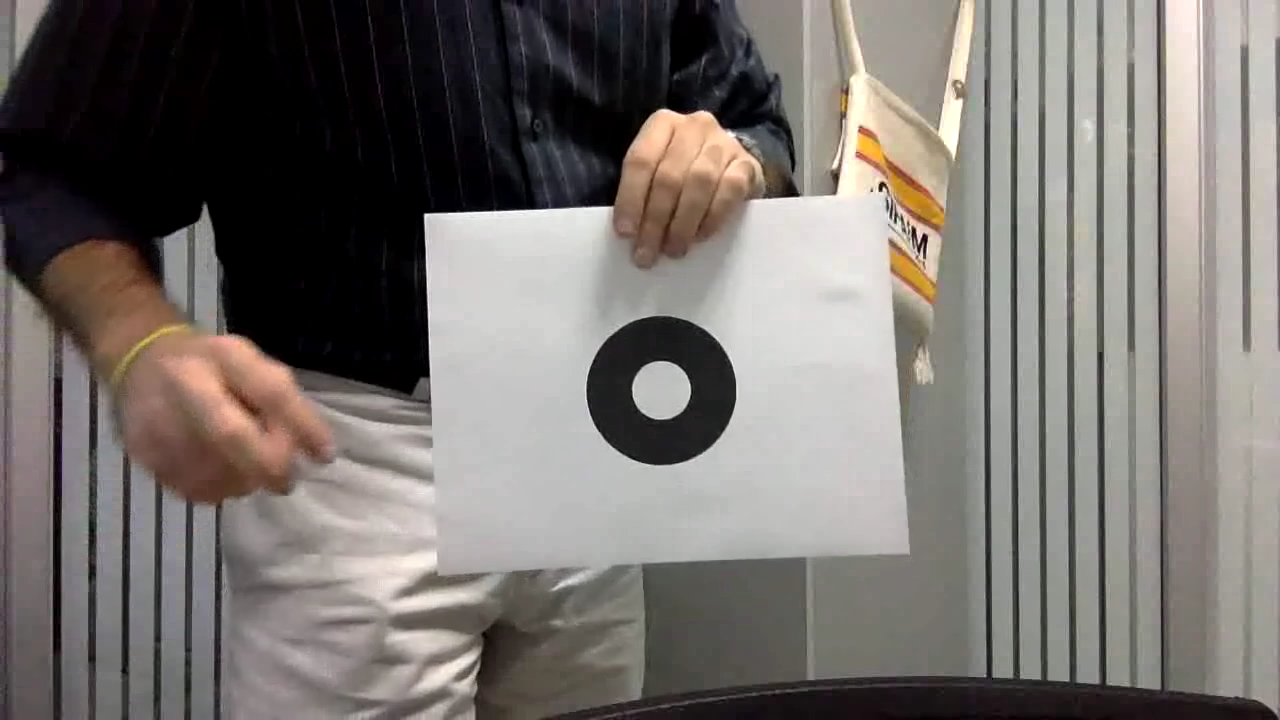

In [2]:
# You can design your program with one of the frames of the video

IMAGE_URL = 'https://github.com/agmarrugo/computer-vision-utb/raw/main/data/oneCC.png'
urllib.request.urlretrieve(IMAGE_URL, 'oneCC.png')

print("Imagen procesada")
img = cv2.imread('oneCC.png')
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
cv2_imshow(img)

In [3]:
# --- Filtrar componentes pequeñas y calcular info básica ---
def extract_components(num_labels, stats, centroids, mask_label):
    comps = []
    for i in range(1, num_labels):  # ignoramos fondo (0)
        area = stats[i, cv2.CC_STAT_AREA]
        if area < 100:
            continue
        x, y, w, h = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
        cx, cy = centroids[i]
        radius = sqrt(area / pi)
        comps.append({
            "label": i,
            "area": area,
            "center": (cx, cy),
            "radius": radius,
            "bbox": (x, y, w, h),
            "mask": (mask_label == i).astype(np.uint8) * 255
        })
    return comps

In [4]:
def ccc_detect(img):
    # --- Copia del frame original ---
    output = img.copy()

    # --- Escala de grises y suavizado ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # --- Umbralización con Otsu (blanco y negro) ---
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, inverse_binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # --- Limpieza morfológica ---
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    inverse_binary = cv2.morphologyEx(inverse_binary, cv2.MORPH_OPEN, kernel)

    # --- Componentes conectadas (foreground y fondo invertido) ---
    num_labels_bin, labels_bin, stats_bin, centroids_bin = cv2.connectedComponentsWithStats(binary, connectivity=8)
    num_labels_inv, labels_inv, stats_inv, centroids_inv = cv2.connectedComponentsWithStats(inverse_binary, connectivity=8)

    comps_dark = extract_components(num_labels_inv, stats_inv, centroids_inv, labels_inv)  # objetos oscuros
    comps_light = extract_components(num_labels_bin, stats_bin, centroids_bin, labels_bin)  # objetos claros

    best_candidate = None
    best_score = 0

    # --- Buscar pares concéntricos (oscuro dentro de claro o viceversa) ---
    for c_dark in comps_dark:
        for c_light in comps_light:
            # Distancia entre centros
            dist = np.hypot(c_dark["center"][0] - c_light["center"][0],
                            c_dark["center"][1] - c_light["center"][1])
            if dist > 5:
                continue

            # Relación de radios
            r_out = max(c_dark["radius"], c_light["radius"])
            r_in = min(c_dark["radius"], c_light["radius"])
            ratio = r_out / (r_in + 1e-6)
            if not (1.2 <= ratio <= 3.5):
                continue

            # Verificar contraste promedio
            mask_ring = cv2.subtract(c_dark["mask"], c_light["mask"]) if c_dark["radius"] > c_light["radius"] else cv2.subtract(c_light["mask"], c_dark["mask"])
            mu_in = cv2.mean(gray, c_light["mask"])[0]
            mu_ring = cv2.mean(gray, mask_ring)[0]
            contrast = abs(mu_in - mu_ring)

            # Puntaje simple
            score = contrast + 0.01 * r_out
            if score > best_score:
                best_score = score
                best_candidate = {
                    "center": c_dark["center"],
                    "r_in": int(r_in),
                    "r_out": int(r_out),      # si quieres seguir devolviéndolo
                    "bbox": c_dark["bbox"],   # guarda el bounding box del anillo oscuro
                }


    # --- Dibujar resultado ---
    if best_candidate:
        cx, cy = map(int, best_candidate["center"])
        x, y, w, h = best_candidate["bbox"]   # <-- rectángulo del componente oscuro

        # Dibuja el rectángulo que ENCERRA el círculo exterior
        cv2.rectangle(output, (int(x), int(y)), (int(x+w), int(y+h)), (255, 0, 255), 2)
        cv2.circle(output, (cx, cy), 2, (255, 0, 255), -1)

        cv2.putText(output, "CCC detectado", (int(x), int(y-10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)

        return True, (cx, cy), best_candidate["r_in"], best_candidate["r_out"], output


    return output


### __Prueba de la función implementada con una imagen aislada__

tomamos un frame del video y probamos para comprobar el correcto funcionamiento

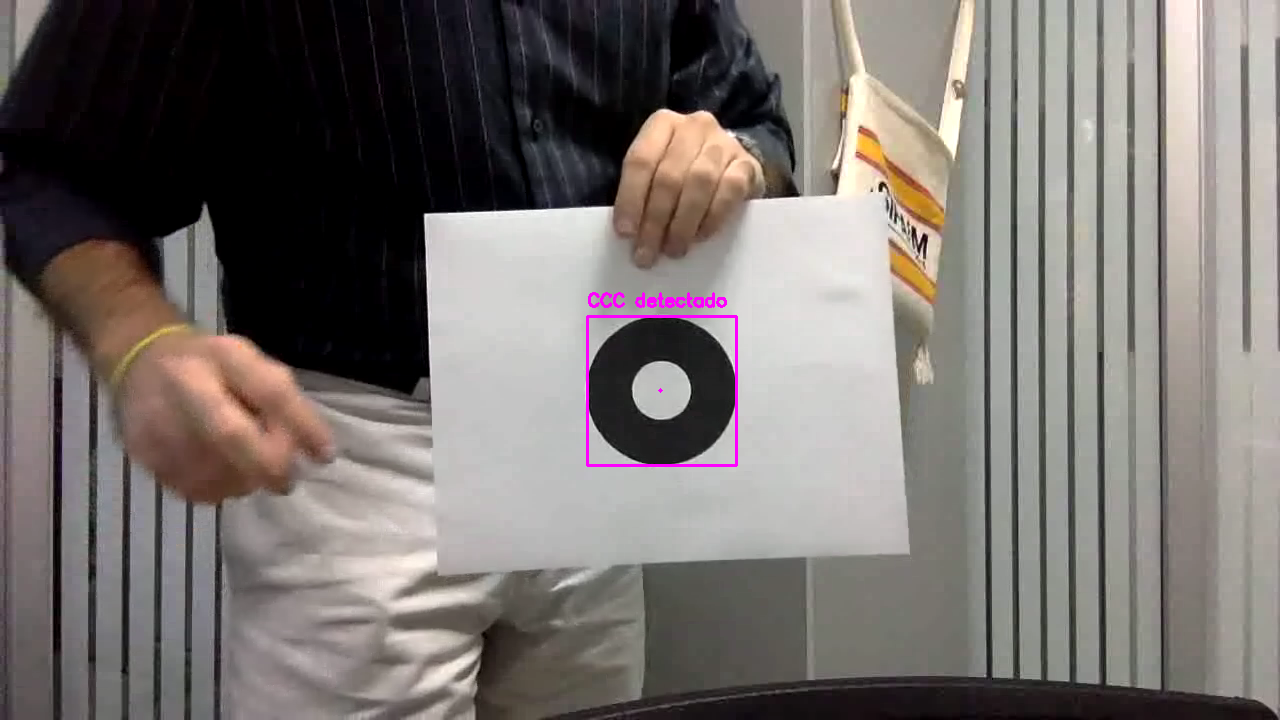

In [5]:
cv2_imshow(ccc_detect(img)[-1])

The following code allows you to read a video file and store as multidimensional array.

In [6]:
VIDEO_URL = 'https://github.com/agmarrugo/computer-vision-utb/raw/main/data/oneCC.mp4'

urllib.request.urlretrieve(VIDEO_URL, 'oneCC.mp4')


# Create a VideoCapture object and read from input file
# If the input is the camera, pass 0 instead of the video file name
cap = cv2.VideoCapture('oneCC.mp4')

# Check if camera opened successfully
if (cap.isOpened()== False):
  print("Error opening video stream or file")

# Read until video is completed
count = 0;

# image_array = np.empty(total) # array which will hold the images
image_array = []

while(cap.isOpened()):
  # Capture frame-by-frame
  ret, frame = cap.read()
  image_array.append(frame)

  if ret == True:
    continue
    # Display the resulting frame
    # cv2_imshow(frame)

  # Break the loop
  else:
    break

# When everything done, release the video capture object
cap.release()

In [7]:
# Finally, write video file by processing all frames

height, width, layers = img.shape
size = (width,height)

out = cv2.VideoWriter('detected_ccc.mp4', cv2.VideoWriter_fourcc(*'MP4V'), 30, size) # 30 fps

for i in range(len(image_array) - 1):

  ccc_detected = ccc_detect(image_array[i])[-1] # ccc_detect() is the function you have to implement

  out.write(ccc_detected)

out.release()

### __Resultado de la ejecución del código__

![](https://github.com/JesusPetro/Vision-Artificial-2P2025/raw/main/semana%2010/detected_ccc.gif)
